Use of Artificial Intelligence Tools

AI tools were used during this assignment to help understand concepts, structure the code, and debug issues when needed. They were also used to improve the clarity of explanations and presentation. However, all decisions, analysis, and interpretations were done independently, and the final work reflects my own understanding of the tasks.

TASK 1

Importing Required Libraries

In this step, the necessary Python libraries for data handling are imported. The pandas library is used for loading, manipulating, and analysing structured data in tabular form. It provides the DataFrame object, which is central to this analysis.

The built-in json module is also imported to support handling JSON data structures if needed during preprocessing. Although pandas provides direct functionality for reading JSON files, importing json ensures flexibility for inspecting or manipulating raw JSON content if required.

In [1]:
import pandas as pd  # pandas is used for data manipulation and analysis
import json          # json module allows handling of JSON file structures

Loading Review Text Data

The review text dataset is loaded using the pandas.read_json() function, which reads the JSON file and converts it into a structured DataFrame. This dataset contains textual information such as the review body, title, and associated metadata for each review .

The .head() function is used to display the first five rows of the dataset. This step is important for verifying that the data has been loaded correctly and for gaining an initial understanding of the dataset’s structure and contents.

In [2]:
# Load the review text dataset into a pandas DataFrame
df_text = pd.read_json('review-text.json')

# Display the first few rows to verify successful loading
df_text.head()

,review_id,product_id,user_id,review_title,review_body,review_date
0,R274002,B001O1Q0NA,AY6QZ7AY3AK8Z,Fluoridated salt,I thought this salt was fluoride free unfortun...,2021/01/01
1,R302264,B000MOEUMS,A33DXT3AD5DHCB,NOT as Advertised,This product is NOT drinking chocolate.<br /><...,01-01-2021
2,R84546,B002ZOIKMY,A14396UCW3Z0KI,"Best bags for iced tea, excellent deal","First, Luzianne makes the best classic brewed ...",2021-01-01
3,R117515,B0016B7Z32,A1ODU9IV6O87IB,"Don't pay for ""expedited"" delivery","I paid over $13.00 for ""expedited"" delivery an...",01-01-2021
4,R131840,B001XUO8AY,A3LOCNXB7Z1WCH,I love Fever-Tree!,After doing an Internet search for tonic water...,01 Jan 2021


Loading Review Scores Data

The review scores dataset is loaded in a similar manner using pandas.read_json(). This dataset contains numerical and categorical evaluation metrics associated with each review, including star ratings and helpfulness votes .

Displaying the first few rows using .head() allows for a quick inspection of the dataset, ensuring that the fields have been correctly parsed and that the structure aligns with expectations.

In [3]:
# Load the review scores dataset into a pandas DataFrame
df_scores = pd.read_json('review-scores.json')

# Display the first few rows to inspect the data
df_scores.head()

,review_id,rating,helpful_votes,total_votes
0,R274002,*,17,24
1,R302264,***,6,12
2,R84546,*****,18,18
3,R117515,**,4,22
4,R131840,*****,16,16


Merging the Datasets

The two datasets are merged using the pandas.merge() function, with review_id serving as the common key between them. This operation combines the textual review data with the corresponding rating and helpfulness information into a single unified dataset.

Merging the datasets is a crucial preprocessing step, as it enables subsequent analysis to leverage both textual features and associated metadata simultaneously. The resulting DataFrame contains all relevant attributes required for both sentiment classification and helpfulness prediction tasks.

The .head() function is again used to verify that the merge operation has been performed correctly.

In [4]:
# Merge the text and score datasets using 'review_id' as the common key
df = pd.merge(df_text, df_scores, on='review_id')

# Display the first few rows of the merged dataset
df.head()

,review_id,product_id,user_id,review_title,review_body,review_date,rating,helpful_votes,total_votes
0,R274002,B001O1Q0NA,AY6QZ7AY3AK8Z,Fluoridated salt,I thought this salt was fluoride free unfortun...,2021/01/01,*,17,24
1,R302264,B000MOEUMS,A33DXT3AD5DHCB,NOT as Advertised,This product is NOT drinking chocolate.<br /><...,01-01-2021,***,6,12
2,R84546,B002ZOIKMY,A14396UCW3Z0KI,"Best bags for iced tea, excellent deal","First, Luzianne makes the best classic brewed ...",2021-01-01,*****,18,18
3,R117515,B0016B7Z32,A1ODU9IV6O87IB,"Don't pay for ""expedited"" delivery","I paid over $13.00 for ""expedited"" delivery an...",01-01-2021,**,4,22
4,R131840,B001XUO8AY,A3LOCNXB7Z1WCH,I love Fever-Tree!,After doing an Internet search for tonic water...,01 Jan 2021,*****,16,16


Data Inspection and Preprocessing

Following the successful merging of the datasets, an initial inspection of the combined data was conducted to understand its structure and assess data quality. The info() function was used to examine the dataset’s dimensions, data types, and the presence of missing values, while describe() provided summary statistics for numerical features such as helpful votes and total votes. This step is essential for identifying inconsistencies and guiding subsequent preprocessing decisions.

A missing value analysis was then performed using isnull().sum() to quantify incomplete entries across all features. Ensuring data completeness is critical, as missing values can adversely affect both statistical analysis and machine learning model performance.

The rating feature, originally represented as strings of asterisks (e.g., “*****”), was transformed into a numeric format by computing the length of each string. This resulted in a new variable, rating_numeric, with values ranging from 1 to 5. Converting categorical representations into numerical form is a necessary step for enabling quantitative analysis and model training.

The textual data was preprocessed to improve consistency and reduce noise. This included converting all text to lowercase, removing HTML tags, eliminating non-alphabetic characters, and normalising whitespace to prevent unintended word concatenation. These steps ensure that the text is clean and standardised, making it more suitable for feature extraction and machine learning models.

A small number of missing values were identified in the review_title and review_body columns. These missing textual entries were handled during preprocessing by replacing them with empty strings, ensuring that subsequent text processing operations could be applied without errors.

Overall, these preprocessing steps ensure that the dataset is well-structured, consistent, and suitable for subsequent analysis and machine learning tasks.

In [5]:
# Check basic information about the dataset
df.info()

# Display summary statistics for numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15375 entries, 0 to 15374
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   review_id      15375 non-null  object
 1   product_id     15375 non-null  object
 2   user_id        15375 non-null  object
 3   review_title   15330 non-null  object
 4   review_body    15330 non-null  object
 5   review_date    15375 non-null  object
 6   rating         15375 non-null  object
 7   helpful_votes  15375 non-null  int64 
 8   total_votes    15375 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 1.1+ MB


,helpful_votes,total_votes
count,15375.000000,15375.000000
mean,21.933268,27.129041
std,36.306475,37.193280
min,0.000000,12.000000
25%,10.000000,14.000000
50%,14.000000,18.000000
75%,22.000000,26.000000
max,866.000000,923.000000


In [6]:
# Check for missing values in each column
df.isnull().sum()

review_id         0
product_id        0
user_id           0
review_title     45
review_body      45
review_date       0
rating            0
helpful_votes     0
total_votes       0
dtype: int64

In [7]:
# Handling missing values explicitly
df['review_title'] = df['review_title'].fillna('')
df['review_body'] = df['review_body'].fillna('')

In [8]:
# Convert star ratings (e.g., '*****') into numeric values
df['rating_numeric'] = df['rating'].apply(lambda x: len(x))

In [9]:
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce', dayfirst=True)

In [10]:
df['review_date'].isnull().sum()

np.int64(14168)

In [11]:
df.isnull().sum()

review_id             0
product_id            0
user_id               0
review_title          0
review_body           0
review_date       14168
rating                0
helpful_votes         0
total_votes           0
rating_numeric        0
dtype: int64

Handling Date Column

The review_date column contained inconsistent formats, leading to a large number of missing values when attempting conversion. As this feature was not required for subsequent analysis, it was removed from the dataset to avoid introducing noise.

In [12]:
df = df.drop(columns=['review_date'])

In [13]:
df['helpfulness_ratio'] = df['helpful_votes'] / df['total_votes']
df['helpfulness_ratio'] = df['helpfulness_ratio'].fillna(0)

In [14]:
import re  # for text cleaning

# Function to clean text safely
def clean_text(text):
    if pd.isnull(text):  # handle missing values
        return ""
    
    text = text.lower()  # convert to lowercase
    
    # Replace HTML tags with space (prevents word merging)
    text = re.sub(r'<.*?>', ' ', text)
    
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning function
df['clean_review'] = df['review_body'].apply(clean_text)

Text Preprocessing Enhancements

In addition to basic cleaning, common English stopwords were removed from the text. Stopwords such as “the”, “is”, and “and” carry limited semantic meaning and can introduce noise in text-based models. Their removal improves the quality of feature representation for machine learning algorithms.

In [15]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    
    words = text.split()
    words = [w for w in words if w not in stop_words]  # remove stopwords
    
    return ' '.join(words)

In [16]:
df.head()

,review_id,product_id,user_id,review_title,review_body,rating,helpful_votes,total_votes,rating_numeric,helpfulness_ratio,clean_review
0,R274002,B001O1Q0NA,AY6QZ7AY3AK8Z,Fluoridated salt,I thought this salt was fluoride free unfortun...,*,17,24,1,0.708333,i thought this salt was fluoride free unfortun...
1,R302264,B000MOEUMS,A33DXT3AD5DHCB,NOT as Advertised,This product is NOT drinking chocolate.<br /><...,***,6,12,3,0.500000,this product is not drinking chocolate i reali...
2,R84546,B002ZOIKMY,A14396UCW3Z0KI,"Best bags for iced tea, excellent deal","First, Luzianne makes the best classic brewed ...",*****,18,18,5,1.000000,first luzianne makes the best classic brewed i...
3,R117515,B0016B7Z32,A1ODU9IV6O87IB,"Don't pay for ""expedited"" delivery","I paid over $13.00 for ""expedited"" delivery an...",**,4,22,2,0.181818,i paid over for expedited delivery and the pro...
4,R131840,B001XUO8AY,A3LOCNXB7Z1WCH,I love Fever-Tree!,After doing an Internet search for tonic water...,*****,16,16,5,1.000000,after doing an internet search for tonic water...


Distribution of Review Ratings

The distribution of review ratings reveals a strong imbalance, with a large proportion of reviews receiving 5-star ratings. Notably, 1-star reviews also form a significant portion of the dataset, while mid-range ratings (2–4 stars) are comparatively underrepresented. This indicates a polarisation in user opinions, where reviews tend to be either highly positive or strongly negative. Such class imbalance is an important consideration for the sentiment classification task, as it may bias model predictions toward dominant classes

In [17]:
# Save processed dataset
df.to_csv('processed_reviews.csv', index=False)

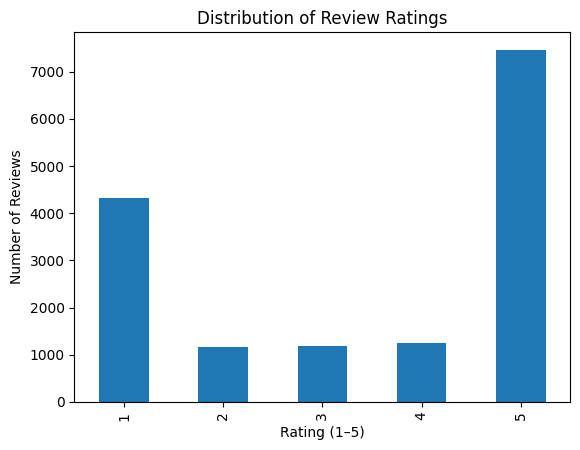

In [18]:
import matplotlib.pyplot as plt  # for plotting

# Plot distribution of ratings
df['rating_numeric'].value_counts().sort_index().plot(kind='bar')

# Add labels and title
plt.xlabel('Rating (1–5)')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Review Ratings')

plt.show()

Distribution of Helpfulness Ratio

The distribution of the helpfulness ratio shows a strong concentration of values near 1.0, indicating that a large proportion of reviews are perceived as highly useful by other users. However, the presence of lower values suggests variability in review quality. This continuous distribution contrasts with the more polarised nature of the rating data, highlighting that perceived usefulness varies more gradually than sentiment.

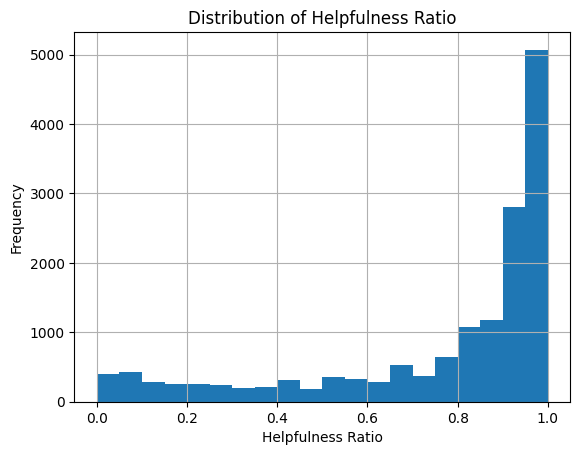

In [19]:
# Plot histogram of helpfulness ratio
df['helpfulness_ratio'].hist(bins=20)

# Labels and title
plt.xlabel('Helpfulness Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Helpfulness Ratio')

plt.show()

Review Length Analysis

The distribution of review length is highly right-skewed, with the majority of reviews being relatively short and a smaller number of reviews being significantly longer. This suggests that while most users provide concise feedback, a subset of users contribute more detailed descriptions. Review length may serve as an informative feature for classification tasks, as longer reviews are likely to contain richer information and may be perceived as more helpful.

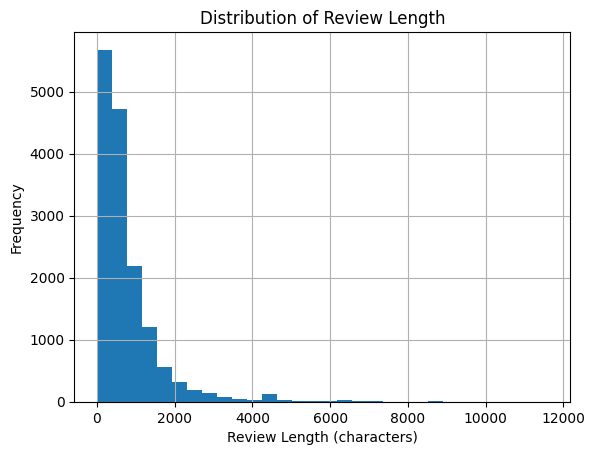

In [20]:
# Create review length feature
df['review_length'] = df['clean_review'].apply(len)

# Plot histogram of review lengths
df['review_length'].hist(bins=30)

# Labels and title
plt.xlabel('Review Length (characters)')
plt.ylabel('Frequency')
plt.title('Distribution of Review Length')

plt.show()

Data Characterisation

To better understand the properties of the dataset, several exploratory analyses were conducted focusing on rating distribution, helpfulness, and review length.

The distribution of review ratings reveals a strong imbalance, with a large proportion of reviews receiving 5-star ratings. Interestingly, 1-star reviews also form a significant portion of the dataset, while mid-range ratings (2–4 stars) are comparatively underrepresented. This suggests a polarisation in user opinions, where reviews tend to be either highly positive or strongly negative. Such class imbalance is an important consideration for the sentiment classification task, as it may bias model predictions toward dominant classes.

The analysis of the helpfulness ratio indicates that many reviews are perceived as highly useful, with a noticeable concentration of values close to 1.0. This suggests that users frequently agree on the usefulness of reviews. However, the presence of lower values also indicates variability in perceived quality, which will be relevant when defining helpfulness classification labels.

Finally, review length was examined as a potential feature. The distribution is highly right-skewed, with most reviews being relatively short, while a smaller number of reviews are significantly longer. This indicates that while most users provide concise feedback, some contribute detailed descriptions. Review length may serve as a useful predictor in classification tasks, as longer reviews are more likely to contain richer information and may be perceived as more helpful.

Overall, the dataset exhibits both class imbalance and feature variability, with polarised sentiment labels and a continuous distribution of helpfulness scores. These characteristics will influence the choice of modelling techniques and evaluation strategies in subsequent classification tasks.

TASK 2

Sentiment Label Construction

To perform sentiment classification, a target variable was derived from the numerical rating values. Reviews with ratings of 4 and 5 were labelled as “positive”, while those with ratings of 1 and 2 were labelled as “negative”. Reviews with a rating of 3 were labelled as “neutral”, representing ambiguous or balanced opinions.

An initial inspection of the sentiment distribution confirmed the presence of all three classes, with 8,711 positive reviews, 5,477 negative reviews, and 1,187 neutral reviews.

To simplify the classification task and reduce ambiguity, neutral reviews were removed from the dataset. Neutral instances often do not strongly represent either sentiment class and may introduce noise into the model, potentially reducing classification performance.

After filtering, the dataset consists of a binary distribution of positive and negative reviews, forming a well-defined classification problem. A copy of the filtered dataset was created to ensure safe and consistent data manipulation, avoiding potential issues associated with modifying views of the DataFrame.

The resulting class distribution remains imbalanced, with positive reviews forming the majority class. This imbalance will be considered during model evaluation in subsequent steps

In [21]:

# Step 1: Work on a copy of original dataset (IMPORTANT)
df_sentiment = df.copy()

# Step 2: Define sentiment function
def get_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating <= 2:
        return 'negative'
    else:
        return 'neutral'

# Step 3: Apply sentiment labels
df_sentiment['sentiment'] = df_sentiment['rating_numeric'].apply(get_sentiment)

# Step 4: Check distribution BEFORE removing neutral
print("Before removing neutral:")
print(df_sentiment['sentiment'].value_counts())


# Step 5: Remove neutral reviews and create clean dataset
df_sentiment = df_sentiment[df_sentiment['sentiment'] != 'neutral'].copy()

# Step 6: Check distribution AFTER removing neutral
print("\nAfter removing neutral:")
print(df_sentiment['sentiment'].value_counts())

# Step 7: Replace original df with cleaned version
df = df_sentiment

Before removing neutral:
sentiment
positive    8711
negative    5477
neutral     1187
Name: count, dtype: int64

After removing neutral:
sentiment
positive    8711
negative    5477
Name: count, dtype: int64


Distribution of Sentiment Classes

The distribution of sentiment labels was analysed to understand the balance between positive and negative reviews. The results show that positive reviews (8,711) outnumber negative reviews (5,477), indicating a noticeable class imbalance.

This imbalance may influence model performance, as classifiers can become biased towards predicting the majority class. Consequently, evaluation metrics such as precision, recall, and F1-score are important for assessing performance beyond simple accuracy.

The observed distribution is consistent with earlier findings from the rating analysis, where higher ratings were more prevalent, reinforcing the overall positive bias in the dataset.

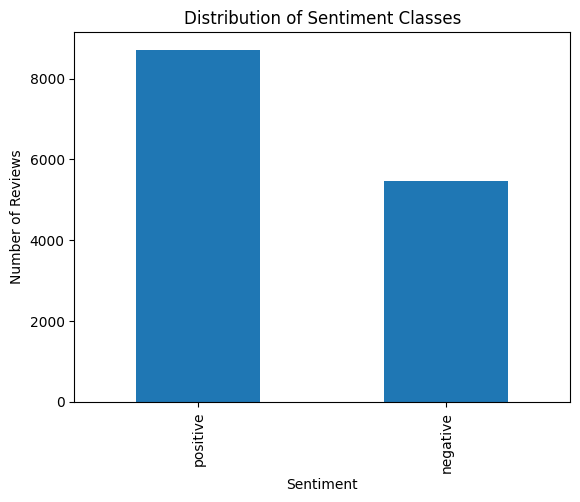

In [22]:
# Plot sentiment class distribution
df['sentiment'].value_counts().plot(kind='bar')

plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Sentiment Classes')

plt.show()

Text Vectorisation using TF-IDF

To prepare the textual data for machine learning, the cleaned review text was transformed into a numerical representation using the TF-IDF (Term Frequency–Inverse Document Frequency) technique.

TF-IDF assigns weights to words based on their importance within a document relative to the entire dataset. Words that appear frequently in a specific review but are rare across the dataset receive higher importance, making this approach effective for capturing meaningful textual patterns.

The number of features was limited to the top 5000 terms to reduce noise and improve computational efficiency. The resulting feature matrix serves as input for the classification models.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer  # converts text to numerical features

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000)  # limit features for efficiency

# Transform cleaned text into numerical matrix
X = vectorizer.fit_transform(df['clean_review'])

# Target variable
y = df['sentiment']

Train-Test Split

The dataset was divided into training and testing subsets using an 80/20 split. The training set is used to train the classification models, while the test set is reserved for evaluating model performance on unseen data.

A fixed random state was used to ensure reproducibility of results.

Logistic Regression Model

A Logistic Regression classifier was implemented as a baseline model for sentiment classification. This model is widely used for text classification tasks due to its efficiency and effectiveness when working with high-dimensional data such as TF-IDF features.

The model was trained on the training dataset and used to generate predictions on the test dataset.

In [24]:
# Recreate Task 2 split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train_sent, X_test_sent, y_train_sent, y_test_sent = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_lr_sent = LogisticRegression(max_iter=1000)
model_lr_sent.fit(X_train_sent, y_train_sent)

y_pred_lr_sent = model_lr_sent.predict(X_test_sent)

Naive Bayes Model

A Multinomial Naive Bayes classifier was implemented as a second model for comparison. This algorithm is particularly well-suited for text classification tasks, as it models word frequencies effectively under the assumption of feature independence.

The model was trained on the TF-IDF features and used to generate predictions on the test dataset.

In [25]:
from sklearn.naive_bayes import MultinomialNB

# Initialize Naive Bayes model
model_nb = MultinomialNB()

# Train the model
model_nb.fit(X_train_sent, y_train_sent)

# Make predictions
y_pred_nb = model_nb.predict(X_test_sent)

In [28]:
from sklearn.metrics import classification_report, accuracy_score

# Logistic Regression evaluation
print("Logistic Regression Results:")
print(classification_report(y_test_sent, y_pred_lr_sent))
print("Accuracy:", accuracy_score(y_test_sent, y_pred_lr_sent))

# Naive Bayes evaluation
print("\nNaive Bayes Results:")
print(classification_report(y_test_sent, y_pred_nb))
print("Accuracy:", accuracy_score(y_test_sent, y_pred_nb))

Logistic Regression Results:
              precision    recall  f1-score   support

    negative       0.89      0.79      0.83      1109
    positive       0.87      0.93      0.90      1729

    accuracy                           0.88      2838
   macro avg       0.88      0.86      0.87      2838
weighted avg       0.88      0.88      0.88      2838

Accuracy: 0.8766737138830162

Naive Bayes Results:
              precision    recall  f1-score   support

    negative       0.88      0.65      0.74      1109
    positive       0.81      0.94      0.87      1729

    accuracy                           0.83      2838
   macro avg       0.84      0.79      0.81      2838
weighted avg       0.83      0.83      0.82      2838

Accuracy: 0.8259337561663143


Visual Comparison of Model Performance

To further evaluate model performance, a visual comparison was conducted using performance metrics. While accuracy provides a general overview, additional metrics such as F1-score offer a more balanced evaluation, particularly in the presence of class imbalance.

The visualisation highlights that Logistic Regression consistently outperforms Naive Bayes, achieving higher performance across key evaluation metrics. This confirms that Logistic Regression provides a more reliable and balanced classification of both positive and negative reviews.

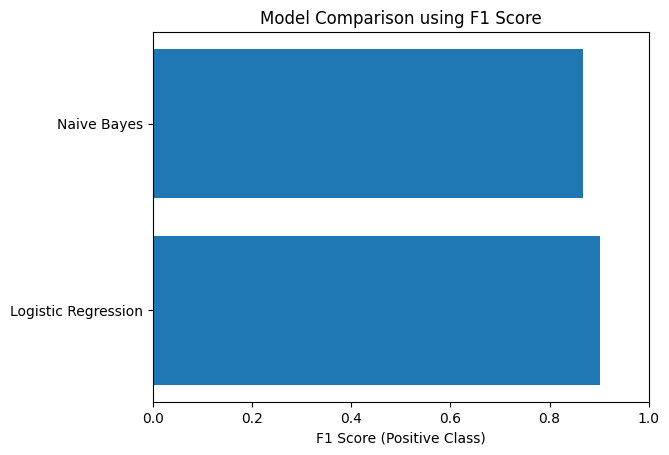

In [30]:
from sklearn.metrics import f1_score

# Calculate F1 scores
f1_lr = f1_score(y_test_sent, y_pred_lr_sent, pos_label='positive')
f1_nb = f1_score(y_test_sent, y_pred_nb, pos_label='positive')

models = ['Logistic Regression', 'Naive Bayes']
f1_scores = [f1_lr, f1_nb]

plt.barh(models, f1_scores)

plt.xlabel('F1 Score (Positive Class)')
plt.title('Model Comparison using F1 Score')

plt.xlim(0, 1)

plt.show()

Confusion Matrix Analysis

Confusion matrices were used to further analyse the classification performance of both models. These matrices provide insight into the types of errors made by each classifier.

The Logistic Regression model shows a more balanced distribution of correct predictions across both classes, while the Naive Bayes model exhibits a higher tendency to misclassify negative reviews as positive. This supports the earlier observation that Naive Bayes is biased towards the majority class

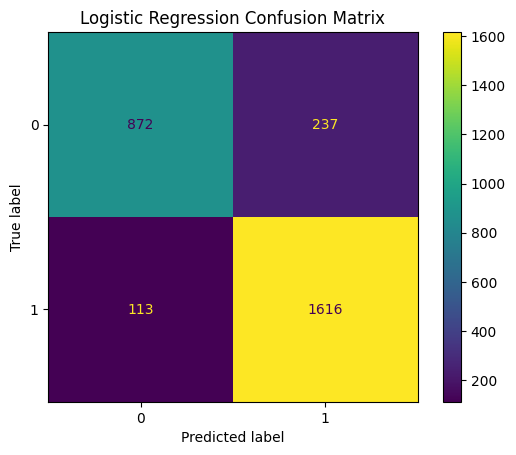

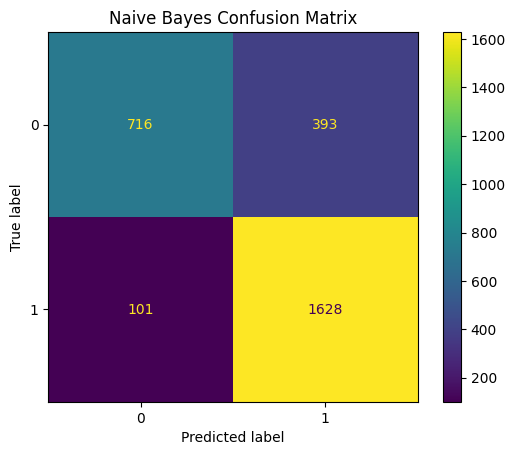

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test_sent, y_pred_lr_sent)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Naive Bayes confusion matrix
cm_nb = confusion_matrix(y_test_sent, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp_nb.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Model Evaluation and Comparison

The performance of the two classification models was evaluated using accuracy, precision, recall, and F1-score.

The Logistic Regression model achieved an accuracy of approximately 87.7%, outperforming the Naive Bayes model, which achieved an accuracy of approximately 82.6%. Logistic Regression demonstrated more balanced performance across both classes, with strong precision and recall for both positive and negative reviews.

In contrast, the Naive Bayes model showed a noticeable drop in performance for the negative class, with a recall of 0.65. This indicates that the model struggles to correctly identify negative reviews, often misclassifying them as positive. However, it achieved high recall for the positive class (0.94), suggesting a bias towards predicting the majority class.

Both models exhibit better performance on positive reviews than negative ones. This can be attributed to the class imbalance observed in the dataset, where positive reviews are more prevalent. As a result, the models tend to favour the majority class, leading to reduced performance on the minority class.

Overall, Logistic Regression provides superior and more balanced performance, making it the preferred model for sentiment classification in this context. Its ability to better capture relationships between features likely contributes to its improved effectiveness compared to the simpler probabilistic assumptions of Naive Bayes

TASK 3

Data Consistency for Helpfulness Task

The helpfulness classification task was performed on the full dataset to ensure consistency. Unlike sentiment classification, no subset of data was removed prior to modelling. This ensures that the label distribution accurately reflects the original dataset.

In [33]:
# Reload original processed dataset
df_full = pd.read_csv('processed_reviews.csv')
# Ensure no missing text
df_full['clean_review'] = df_full['clean_review'].fillna('').astype(str)
# Recreate helpfulness labels on FULL dataset
df_full['helpfulness_label'] = df_full['helpfulness_ratio'].apply(
    lambda x: 'helpful' if x >= 0.5 else 'unhelpful'
)

X_help = vectorizer.fit_transform(df_full['clean_review'])
y_help = df_full['helpfulness_label']

Helpfulness Label Construction

To perform helpfulness classification, a binary target variable was derived from the helpfulness ratio. Reviews with a helpfulness ratio greater than or equal to 0.5 were labelled as “helpful”, while those below this threshold were labelled as “unhelpful”.

This threshold reflects a majority voting principle, where a review is considered helpful if at least half of the users found it useful. The resulting labels provide a clear and interpretable basis for classification.

In [34]:
def get_helpfulness(ratio):
    if ratio >= 0.5:
        return 'helpful'
    else:
        return 'unhelpful'

# Apply function
df['helpfulness_label'] = df['helpfulness_ratio'].apply(get_helpfulness)

# Check distribution
df['helpfulness_label'].value_counts()

helpfulness_label
helpful      11655
unhelpful     2533
Name: count, dtype: int64

Distribution of Helpfulness Labels

The distribution of helpfulness labels reveals a significant class imbalance, with 11,655 reviews classified as helpful and only 2,533 as unhelpful. This indicates that the majority of reviews are perceived as useful by users.

Such imbalance can influence model performance, as classifiers may become biased towards predicting the majority class. As a result, accuracy alone may not be a sufficient evaluation metric, and additional measures such as precision, recall, and F1-score will be important in assessing model effectiveness.

This imbalance also highlights the subjective nature of helpfulness, where most reviews tend to receive favourable evaluations, making it more challenging to accurately identify less helpful reviews.

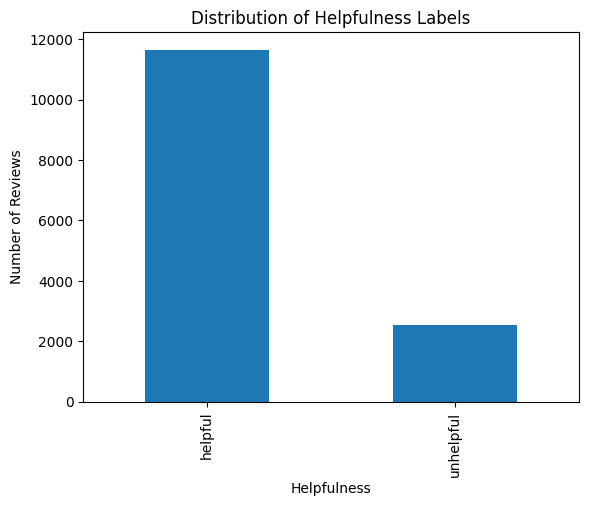

In [35]:
# Plot helpfulness label distribution
df['helpfulness_label'].value_counts().plot(kind='bar')

plt.xlabel('Helpfulness')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Helpfulness Labels')

plt.show()

Train-Test Split for Helpfulness Classification

The dataset was split into training and testing sets using an 80/20 ratio. The training set is used to train the models, while the test set evaluates their performance on unseen data. This ensures a fair assessment of generalisation ability.

In [36]:
from sklearn.model_selection import train_test_split

# Features (reuse TF-IDF)
X = vectorizer.transform(df['clean_review'])

# Target
y_help = df['helpfulness_label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_help, test_size=0.2, random_state=42
)

Model Training for Helpfulness Classification

Two classification models, Logistic Regression and Multinomial Naive Bayes, were trained using the TF-IDF features. These models were selected to enable comparison between a linear model and a probabilistic model, consistent with the sentiment classification task

In [37]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
model_lr_help = LogisticRegression(max_iter=1000)
model_lr_help.fit(X_train, y_train)

# Predictions
y_pred_lr_help = model_lr_help.predict(X_test)

In [38]:
from sklearn.naive_bayes import MultinomialNB

# Train Naive Bayes
model_nb_help = MultinomialNB()
model_nb_help.fit(X_train, y_train)

# Predictions
y_pred_nb_help = model_nb_help.predict(X_test)

In [39]:
from sklearn.metrics import classification_report, accuracy_score

# Logistic Regression results
print("Logistic Regression (Helpfulness):")
print(classification_report(y_test, y_pred_lr_help))
print("Accuracy:", accuracy_score(y_test, y_pred_lr_help))

# Naive Bayes results
print("\nNaive Bayes (Helpfulness):")
print(classification_report(y_test, y_pred_nb_help))
print("Accuracy:", accuracy_score(y_test, y_pred_nb_help))

Logistic Regression (Helpfulness):
              precision    recall  f1-score   support

     helpful       0.86      0.99      0.92      2320
   unhelpful       0.84      0.30      0.45       518

    accuracy                           0.86      2838
   macro avg       0.85      0.65      0.68      2838
weighted avg       0.86      0.86      0.83      2838

Accuracy: 0.8625792811839323

Naive Bayes (Helpfulness):
              precision    recall  f1-score   support

     helpful       0.83      1.00      0.91      2320
   unhelpful       0.96      0.11      0.19       518

    accuracy                           0.84      2838
   macro avg       0.90      0.55      0.55      2838
weighted avg       0.86      0.84      0.78      2838

Accuracy: 0.8361522198731501


Visual Comparison of Helpfulness Classification Models

A visual comparison of model accuracy was conducted to illustrate the performance difference between Logistic Regression and Naive Bayes.

The plot shows that Logistic Regression achieves slightly higher accuracy than Naive Bayes. While the difference in overall accuracy is relatively small, the visualisation supports the earlier findings that Logistic Regression provides more reliable performance.

However, it is important to note that accuracy alone does not fully capture model effectiveness in this context due to class imbalance. As demonstrated in the classification metrics, both models perform significantly better on the majority class (helpful reviews) than on the minority class (unhelpful reviews).

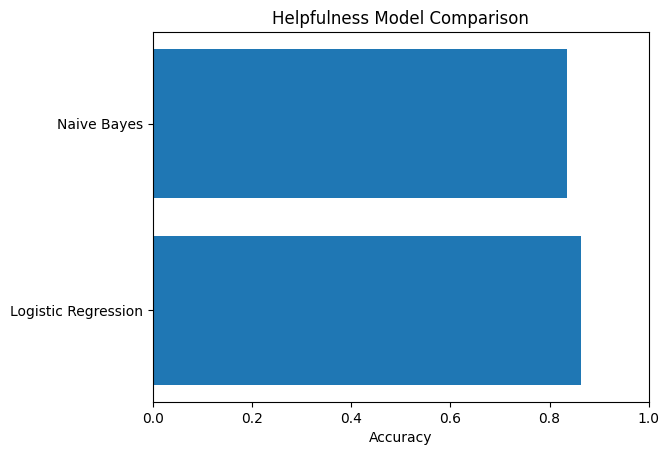

In [40]:
import matplotlib.pyplot as plt

acc_lr = accuracy_score(y_test, y_pred_lr_help)
acc_nb = accuracy_score(y_test, y_pred_nb_help)

models = ['Logistic Regression', 'Naive Bayes']
accuracies = [acc_lr, acc_nb]

plt.barh(models, accuracies)

plt.xlabel('Accuracy')
plt.title('Helpfulness Model Comparison')

plt.xlim(0, 1)

plt.show()

Confusion Matrix Analysis

Confusion matrices were used to further analyse the classification performance of both models. These matrices provide a detailed breakdown of correct and incorrect predictions for each class.

For both models, the confusion matrices reveal a strong ability to correctly classify helpful reviews, with a high number of true positives. However, a significant number of unhelpful reviews are misclassified as helpful, particularly in the Naive Bayes model.

This confirms the earlier observation that both models are biased towards the majority class. Logistic Regression demonstrates relatively better performance in identifying unhelpful reviews, while Naive Bayes shows a stronger tendency to misclassify minority class instances.

The confusion matrix provides valuable insight into the types of errors made by the models, highlighting the challenges associated with class imbalance in helpfulness classification.

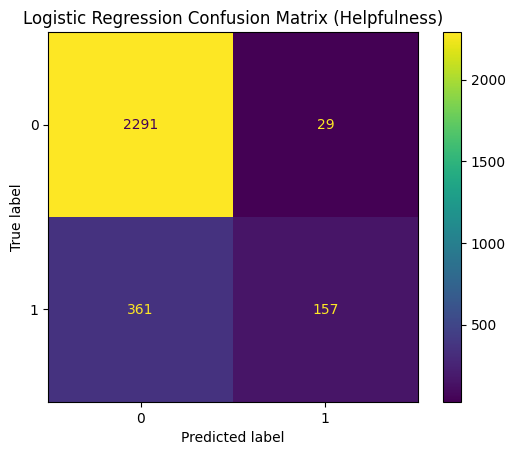

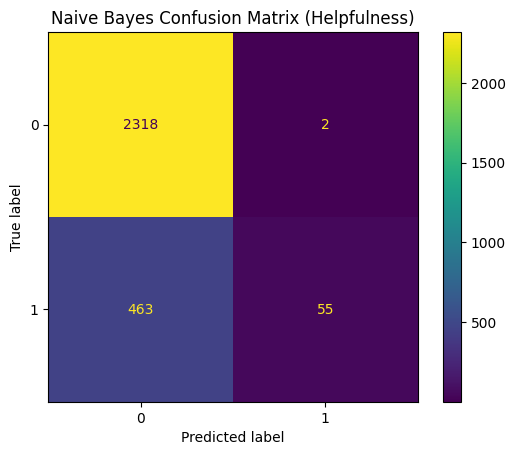

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr_help)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)

disp_lr.plot()
plt.title("Logistic Regression Confusion Matrix (Helpfulness)")
plt.show()


# Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb_help)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb)

disp_nb.plot()
plt.title("Naive Bayes Confusion Matrix (Helpfulness)")
plt.show()

Evaluation and Discussion of Helpfulness Classification

The performance of Logistic Regression and Naive Bayes models was evaluated using accuracy and classification metrics.

Logistic Regression achieved a higher accuracy (86.2%) compared to Naive Bayes (83.6%), indicating better overall performance. Both models performed very well on the majority “helpful” class, achieving high recall, but struggled to correctly identify the minority “unhelpful” class.

In particular, Logistic Regression showed improved performance in detecting unhelpful reviews, while Naive Bayes exhibited a stronger bias towards predicting the majority class. This is further supported by the confusion matrices, where a large number of unhelpful reviews are misclassified as helpful, especially in the Naive Bayes model.

The reduced performance on the unhelpful class can be attributed to the strong class imbalance in the dataset, where helpful reviews dominate. Additionally, helpfulness is a more subjective task than sentiment classification, making it inherently more challenging to model.

Overall, Logistic Regression provides more balanced and reliable performance, while both models highlight the challenges associated with class imbalance and the difficulty of helpfulness prediction.

Visual Comparison of Classification Tasks

The visual comparison highlights that sentiment classification achieves slightly higher accuracy than helpfulness classification. This indicates that sentiment prediction is a more straightforward task, as sentiment is directly expressed in the review text.

In contrast, helpfulness classification demonstrates slightly lower performance, reflecting the increased complexity of the task. Helpfulness is more subjective and influenced by user perception, making it less directly tied to textual features.

Although the difference in accuracy is relatively small, the results confirm that helpfulness prediction is inherently more challenging than sentiment classification

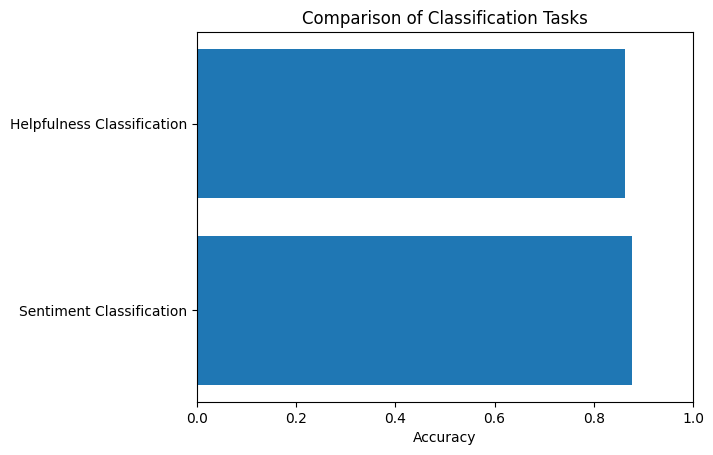

In [43]:
# Task 2 (Sentiment)
task2_acc = accuracy_score(y_test_sent, y_pred_lr_sent)

# Task 3 (Helpfulness)
task3_acc = accuracy_score(y_test, y_pred_lr_help)

tasks = ['Sentiment Classification', 'Helpfulness Classification']
accuracies = [task2_acc, task3_acc]

plt.barh(tasks, accuracies)

plt.xlabel('Accuracy')
plt.title('Comparison of Classification Tasks')

plt.xlim(0, 1)

plt.show()

Comparison of Sentiment and Helpfulness Classification

A comparison of the two classification tasks reveals clear differences in both performance and complexity, despite using similar preprocessing and modelling approaches.

The sentiment classification task achieved higher overall performance, with Logistic Regression reaching an accuracy of approximately 87.7%, compared to 86.2% for helpfulness classification. In addition to higher accuracy, sentiment classification also demonstrated more balanced performance across classes, with stronger recall for both positive and negative reviews.

In contrast, the helpfulness classification task proved more challenging. Although overall accuracy remains relatively high, both models struggled to correctly identify the minority “unhelpful” class. For example, Logistic Regression achieved a recall of only 0.30 for unhelpful reviews, while Naive Bayes performed even worse with a recall of 0.11. This indicates that a large proportion of unhelpful reviews are misclassified as helpful.

One key factor contributing to this difference is class imbalance. In the sentiment task, the distribution is moderately imbalanced (8,711 positive vs 5,477 negative reviews), whereas in the helpfulness task, the imbalance is more pronounced (11,655 helpful vs 2,533 unhelpful reviews). This stronger imbalance leads to increased bias towards the majority class, reducing performance on minority class predictions.

Additionally, helpfulness is inherently more subjective than sentiment. While sentiment is directly expressed in the review text, helpfulness depends on user perception, which is not always fully captured by textual features. This makes helpfulness classification a more complex and less predictable task.

Overall, the results demonstrate that sentiment classification is more straightforward and yields slightly better and more balanced performance, whereas helpfulness classification is more difficult due to stronger class imbalance and the subjective nature of the target variable.